# Step 2: Exploratory Data Analysis (EDA)

In this step, we explore the dataset to understand distributions, relationships, and key cost drivers affecting medical insurance charges.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("insurance_clean.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1337, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 1. Dataset Overview
We start by summarizing the dataset structure and basic statistics.

In [2]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [3]:
df.describe(include='object')

,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


## 2. Distribution of Insurance Charges (Target Variable)

We analyze the distribution of the target variable to understand how medical costs are spread.

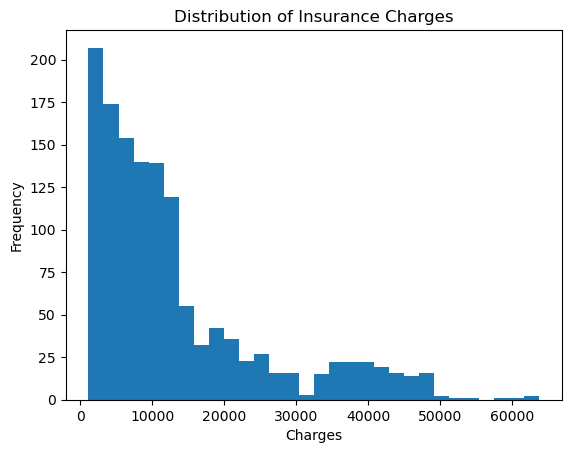

In [4]:
plt.figure()
plt.hist(df['charges'], bins=30)
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

## 3. Age vs Insurance Charges

We examine whether older individuals tend to have higher insurance costs.

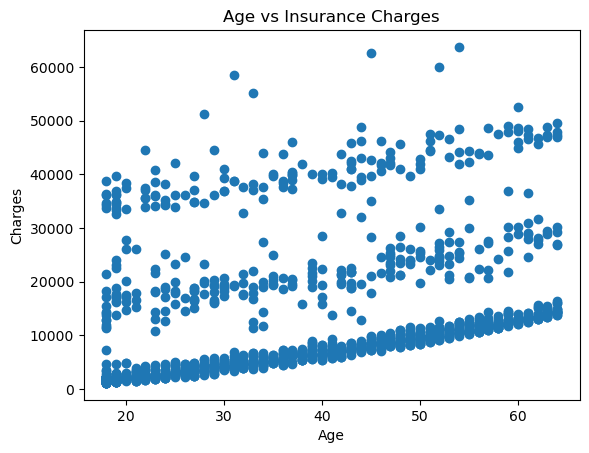

In [5]:
plt.figure()
plt.scatter(df['age'], df['charges'])
plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

## 4. BMI vs Insurance Charges

We analyze the relationship between BMI and medical costs.

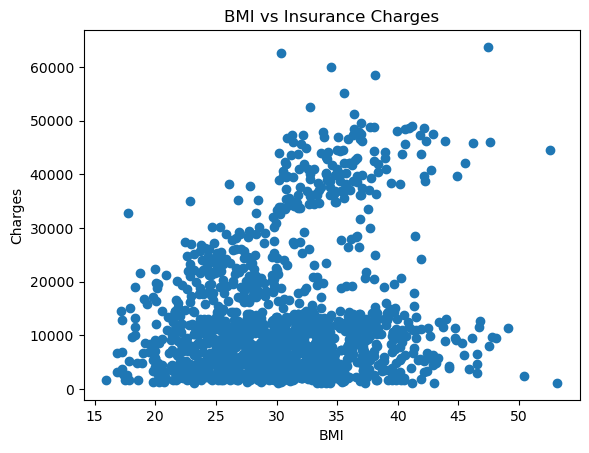

In [6]:
plt.figure()
plt.scatter(df['bmi'], df['charges'])
plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

## 5. Smoking Status vs Insurance Charges

Smoking is expected to be one of the strongest predictors of insurance costs.

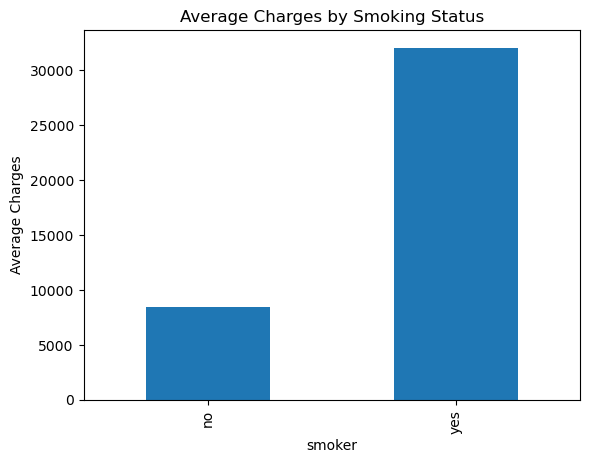

In [7]:
smoker_avg = df.groupby("smoker")["charges"].mean()

plt.figure()
smoker_avg.plot(kind='bar')
plt.title("Average Charges by Smoking Status")
plt.ylabel("Average Charges")
plt.show()

## 6. Gender vs Insurance Charges

We check whether insurance costs differ by gender.

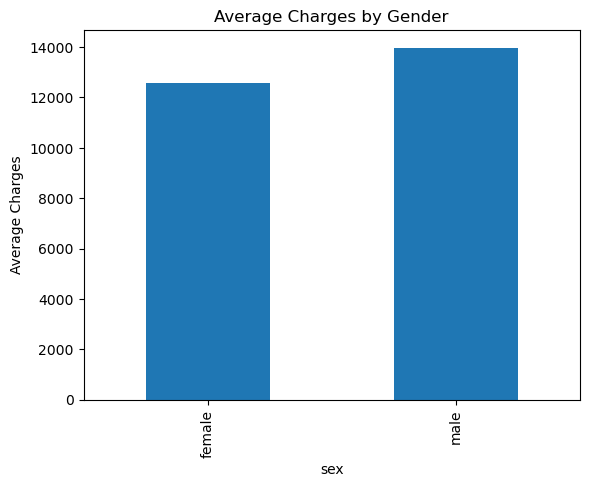

In [8]:
sex_avg = df.groupby("sex")["charges"].mean()

plt.figure()
sex_avg.plot(kind='bar')
plt.title("Average Charges by Gender")
plt.ylabel("Average Charges")
plt.show()

## 7. Region vs Insurance Charges

We explore whether geographical region impacts insurance costs.

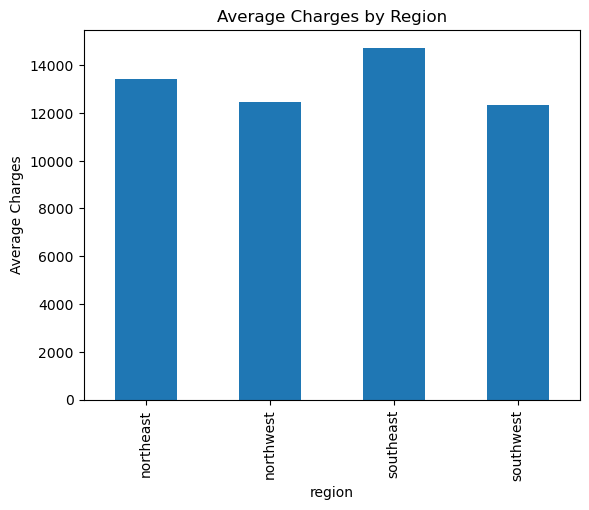

In [9]:
region_avg = df.groupby("region")["charges"].mean()

plt.figure()
region_avg.plot(kind='bar')
plt.title("Average Charges by Region")
plt.ylabel("Average Charges")
plt.show()

## 8. Number of Children vs Insurance Charges

We analyze whether family size influences insurance costs.

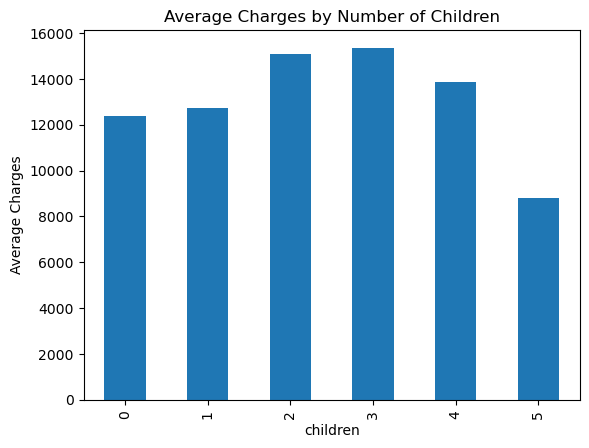

In [10]:
children_avg = df.groupby("children")["charges"].mean()

plt.figure()
children_avg.plot(kind='bar')
plt.title("Average Charges by Number of Children")
plt.ylabel("Average Charges")
plt.show()

## 9. Correlation Analysis

We examine relationships between numerical variables.

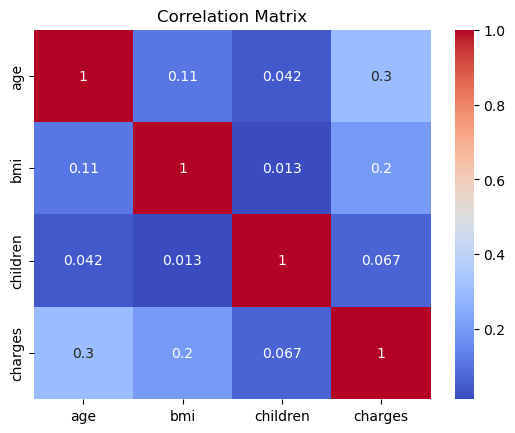

In [13]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure()
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## 10. Interaction: Smoking vs BMI

We analyze how BMI and smoking together affect insurance costs.

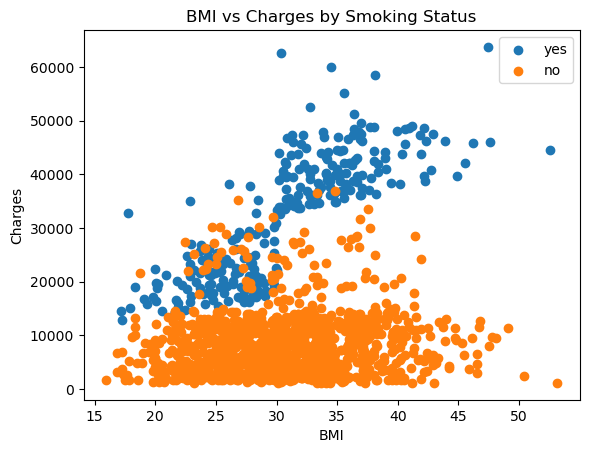

In [14]:
plt.figure()

for smoker_status in df['smoker'].unique():
    subset = df[df['smoker'] == smoker_status]
    plt.scatter(subset['bmi'], subset['charges'], label=smoker_status)

plt.title("BMI vs Charges by Smoking Status")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.legend()
plt.show()

# Key Insights from EDA

- Insurance charges are highly right-skewed
- Smoking is the strongest driver of medical costs
- Age shows a positive relationship with charges
- BMI is moderately correlated with higher costs
- Gender and region have weak influence on charges
- Interaction between BMI and smoking significantly increases costs
- Dataset is suitable for predictive modeling (regression analysis)